# 台灣避難所洪災風險分析
## 多級河川警戒緩衝區、避難所風險評估與收容量缺口分析

本作業整合：
- 水利署河川面圖資
- 消防署避難收容所資料
- 鄉鎮市區界線資料

分析流程依序包含：
1. 資料載入與清理
2. 多級緩衝區分析
3. 收容量缺口分析
4. 視覺化呈現

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

from shapely.geometry import Point
from dotenv import load_dotenv
from IPython.display import display

# 中文字體設定
plt.rcParams['font.sans-serif'] = [
    'Microsoft JhengHei',
    'Microsoft YaHei',
    'SimHei',
    'Arial Unicode MS'
]
plt.rcParams['axes.unicode_minus'] = False

# 載入 .env
load_dotenv()

BUFFER_HIGH = int(os.getenv("BUFFER_HIGH", 500))
BUFFER_MED = int(os.getenv("BUFFER_MED", 1000))
BUFFER_LOW = int(os.getenv("BUFFER_LOW", 2000))

TARGET_COUNTIES = os.getenv("TARGET_COUNTIES", "ALL")

RIVER_SHAPEFILE_PATH = os.getenv("RIVER_SHAPEFILE_PATH", "data/riverpoly/riverpoly.shp")
SHELTER_CSV_PATH = os.getenv("SHELTER_CSV_PATH", "data/避難收容處所點位檔案v9.csv")
TOWNSHIP_SHAPEFILE_DIR = os.getenv("TOWNSHIP_SHAPEFILE_DIR", "data/鄉(鎮、市、區)界線1140318")

TARGET_CRS = os.getenv("TARGET_CRS", "EPSG:3826")
SOURCE_CRS = os.getenv("SOURCE_CRS", "EPSG:4326")

EVACUATION_RATE = float(os.getenv("EVACUATION_RATE", 0.2))
MIN_SHELTER_CAPACITY = int(os.getenv("MIN_SHELTER_CAPACITY", 50))

OUTPUT_DIR = os.getenv("OUTPUT_DIR", "output")
MAP_DPI = int(os.getenv("MAP_DPI", 300))
CHART_WIDTH = int(os.getenv("CHART_WIDTH", 16))
CHART_HEIGHT = int(os.getenv("CHART_HEIGHT", 12))

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ 環境設定完成")
print(f"BUFFER_HIGH = {BUFFER_HIGH}")
print(f"BUFFER_MED = {BUFFER_MED}")
print(f"BUFFER_LOW = {BUFFER_LOW}")
print(f"TARGET_CRS = {TARGET_CRS}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

✅ 環境設定完成
BUFFER_HIGH = 500
BUFFER_MED = 1000
BUFFER_LOW = 2000
TARGET_CRS = EPSG:3826
OUTPUT_DIR = output


## A. 資料載入與清理

本節依序完成以下工作：

1. 讀取水利署河川面 Shapefile，檢查其座標系統（CRS）
2. 讀取消防署避難所 CSV，確認經緯度欄位
3. 先以座標值規則清理無效點位（如座標為 0、缺值、超出台灣經緯度範圍）
4. 再利用鄉鎮市區界線進行空間清理，只保留位於台灣本島與離島行政區範圍內的避難所點位，排除海上異常點
5. 將避難所資料轉為 GeoDataFrame，並統一轉換至 EPSG:3826
6. 讀取鄉鎮市區界線資料，並統一轉換至 EPSG:3826

此步驟的目的，是確保後續多級緩衝區分析與空間連接建立在一致且可信的空間資料基礎上。

In [2]:
print("📥 開始讀取基礎資料...")

# --------------------------------------------------
# 1. 讀取河川圖資
# --------------------------------------------------
rivers_gdf = gpd.read_file(RIVER_SHAPEFILE_PATH)

print("✅ 河川圖資讀取成功")
print(f"   筆數: {len(rivers_gdf)}")
print(f"   CRS: {rivers_gdf.crs}")


# --------------------------------------------------
# 2. 讀取避難所 CSV
# --------------------------------------------------
shelters_df = pd.read_csv(SHELTER_CSV_PATH, encoding="utf-8")

print("\n✅ 避難所 CSV 讀取成功")
print(f"   筆數: {len(shelters_df)}")
print(f"   欄位: {list(shelters_df.columns)}")


# --------------------------------------------------
# 3. 讀取鄉鎮界
# --------------------------------------------------
shp_files = [f for f in os.listdir(TOWNSHIP_SHAPEFILE_DIR) if f.endswith(".shp")]

if len(shp_files) == 0:
    raise FileNotFoundError("找不到鄉鎮界 shapefile")

township_shp_path = os.path.join(TOWNSHIP_SHAPEFILE_DIR, shp_files[0])

townships_gdf = gpd.read_file(township_shp_path)

print("\n✅ 鄉鎮界資料讀取成功")
print(f"   筆數: {len(townships_gdf)}")
print(f"   CRS: {townships_gdf.crs}")
print(f"   欄位: {list(townships_gdf.columns)}")


# --------------------------------------------------
# 4. 讀取行政區常住人口資料
# --------------------------------------------------
POPULATION_CSV_PATH = "data/114年6月行政區人口統計_鄉鎮市區.csv"

population_df = pd.read_csv(POPULATION_CSV_PATH, encoding="utf-8")

print("\n✅ 行政區人口資料讀取成功")
print(f"   筆數: {len(population_df)}")
print(f"   欄位: {list(population_df.columns)}")

# 顯示前幾筆確認資料
print("\n人口資料樣本：")
display(population_df.head())

📥 開始讀取基礎資料...
✅ 河川圖資讀取成功
   筆數: 13262
   CRS: EPSG:3826

✅ 避難所 CSV 讀取成功
   筆數: 5973
   欄位: ['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置']

✅ 鄉鎮界資料讀取成功
   筆數: 368
   CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
   欄位: ['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']

✅ 行政區人口資料讀取成功
   筆數: 369
   欄位: ['COUNTY_ID', 'COUNTY', 'TOWN_ID', 'TOWN', 'H_CNT', 'P_CNT', 'M_CNT', 'F_CNT', 'INFO_TIME']

人口資料樣本：


,COUNTY_ID,COUNTY,TOWN_ID,TOWN,H_CNT,P_CNT,M_CNT,F_CNT,INFO_TIME
0,縣市代碼,縣市名稱,鄉鎮市區代碼,鄉鎮市區名稱,戶數,人口數,男性人口數,女性人口數,資料時間
1,65000,新北市,65000010,板橋區,237657,551502,266292,285210,114Y06M
2,65000,新北市,65000020,三重區,171571,383094,186768,196326,114Y06M
3,65000,新北市,65000030,中和區,182037,404848,194327,210521,114Y06M
4,65000,新北市,65000040,永和區,95744,212634,100104,112530,114Y06M


In [3]:
print("🧹 開始清理避難所資料...")

# --------------------------------------------------
# 1. 檢查並統一河川、鄉鎮界 CRS
# --------------------------------------------------
print("🔄 檢查並統一 CRS...")

if str(rivers_gdf.crs) != TARGET_CRS:
    rivers_gdf = rivers_gdf.to_crs(TARGET_CRS)

if str(townships_gdf.crs) != TARGET_CRS:
    townships_gdf = townships_gdf.to_crs(TARGET_CRS)

print(f"河川 CRS: {rivers_gdf.crs}")
print(f"鄉鎮界 CRS: {townships_gdf.crs}")

# --------------------------------------------------
# 2. 自動判斷避難所經緯度欄位
# --------------------------------------------------
lon_col, lat_col = None, None

if 'lon' in shelters_df.columns and 'lat' in shelters_df.columns:
    lon_col, lat_col = 'lon', 'lat'
elif '經度' in shelters_df.columns and '緯度' in shelters_df.columns:
    lon_col, lat_col = '經度', '緯度'
else:
    raise ValueError("找不到經緯度欄位，請檢查 shelter CSV")

print(f"使用經緯度欄位：{lon_col}, {lat_col}")

# --------------------------------------------------
# 3. 經緯度轉數值
# --------------------------------------------------
shelters_df[lon_col] = pd.to_numeric(shelters_df[lon_col], errors='coerce')
shelters_df[lat_col] = pd.to_numeric(shelters_df[lat_col], errors='coerce')

original_count = len(shelters_df)

# --------------------------------------------------
# 4. 第一階段清理：刪除 0 / NaN / 明顯超出台灣範圍
# --------------------------------------------------
invalid_coord_mask = (
    shelters_df[lon_col].isna() |
    shelters_df[lat_col].isna() |
    (shelters_df[lon_col] == 0) |
    (shelters_df[lat_col] == 0) |
    (shelters_df[lon_col] < 118) |
    (shelters_df[lon_col] > 123.5) |
    (shelters_df[lat_col] < 21) |
    (shelters_df[lat_col] > 26.5)
)

shelters_step1_df = shelters_df.loc[~invalid_coord_mask].copy()

step1_count = len(shelters_step1_df)
removed_step1 = original_count - step1_count

print("\n📍 第一階段座標清理完成")
print(f"原始筆數: {original_count}")
print(f"第一階段清理後筆數: {step1_count}")
print(f"第一階段移除筆數: {removed_step1}")

# --------------------------------------------------
# 5. 轉成 GeoDataFrame（WGS84 -> EPSG:3826）
# --------------------------------------------------
shelters_gdf = gpd.GeoDataFrame(
    shelters_step1_df,
    geometry=gpd.points_from_xy(shelters_step1_df[lon_col], shelters_step1_df[lat_col]),
    crs=SOURCE_CRS
)

if str(shelters_gdf.crs) != TARGET_CRS:
    shelters_gdf = shelters_gdf.to_crs(TARGET_CRS)

print(f"\n避難所 CRS: {shelters_gdf.crs}")

# --------------------------------------------------
# 6. 第二階段清理：用鄉鎮界 polygon 保留台灣本島與離島行政區內點位
# --------------------------------------------------
print("🗺️ 使用鄉鎮市區界線進行空間清理...")

# 將所有鄉鎮界合併成一個台灣行政區範圍
taiwan_admin_union = townships_gdf.unary_union

taiwan_admin_gdf = gpd.GeoDataFrame(
    {'name': ['Taiwan_admin_area']},
    geometry=[taiwan_admin_union],
    crs=TARGET_CRS
)

# 只保留落在鄉鎮界範圍內的避難所
shelters_clean_gdf = gpd.sjoin(
    shelters_gdf,
    taiwan_admin_gdf,
    how='inner',
    predicate='within'
).drop(columns=['index_right'])

step2_count = len(shelters_clean_gdf)
removed_step2 = step1_count - step2_count
total_removed = original_count - step2_count

print("\n📍 第二階段空間清理完成")
print(f"第一階段後筆數: {step1_count}")
print(f"第二階段後筆數: {step2_count}")
print(f"第二階段移除筆數: {removed_step2}")
print(f"總移除筆數: {total_removed}")

# --------------------------------------------------
# 7. 若有設定目標縣市，可進一步篩選
# --------------------------------------------------
if TARGET_COUNTIES != "ALL":
    target_county_list = [x.strip() for x in TARGET_COUNTIES.split(",")]
    county_col = None
    
    for c in ['縣市', 'COUNTYNAME', 'COUNTY', 'county_name']:
        if c in shelters_clean_gdf.columns:
            county_col = c
            break
    
    if county_col is not None:
        before_filter = len(shelters_clean_gdf)
        shelters_clean_gdf = shelters_clean_gdf[
            shelters_clean_gdf[county_col].isin(target_county_list)
        ].copy()
        after_filter = len(shelters_clean_gdf)
        
        print("\n🎯 已套用目標縣市篩選")
        print(f"目標縣市: {target_county_list}")
        print(f"篩選前筆數: {before_filter}")
        print(f"篩選後筆數: {after_filter}")
    else:
        print("\n⚠️ 找不到縣市欄位，無法套用 TARGET_COUNTIES 篩選")

# --------------------------------------------------
# 8. 最終結果
# --------------------------------------------------
print("\n✅ 避難所資料清理完成")
print(f"最終避難所筆數: {len(shelters_clean_gdf)}")

print("\n資料摘要：")
print(f"- 原始資料筆數: {original_count}")
print(f"- 第一階段（座標值）移除: {removed_step1}")
print(f"- 第二階段（空間清理）移除: {removed_step2}")
print(f"- 最終保留筆數: {len(shelters_clean_gdf)}")

# 後續分析統一使用 shelters_gdf 這個名稱
shelters_gdf = shelters_clean_gdf.copy()

print("\nCRS 最終確認：")
print(f"河川 CRS: {rivers_gdf.crs}")
print(f"避難所 CRS: {shelters_gdf.crs}")
print(f"鄉鎮界 CRS: {townships_gdf.crs}")

🧹 開始清理避難所資料...
🔄 檢查並統一 CRS...
河川 CRS: EPSG:3826
鄉鎮界 CRS: EPSG:3826
使用經緯度欄位：經度, 緯度

📍 第一階段座標清理完成
原始筆數: 5973
第一階段清理後筆數: 5947
第一階段移除筆數: 26

避難所 CRS: EPSG:3826
🗺️ 使用鄉鎮市區界線進行空間清理...


C:\Users\User\AppData\Local\Temp\ipykernel_27052\1844022250.py:83: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  taiwan_admin_union = townships_gdf.unary_union



📍 第二階段空間清理完成
第一階段後筆數: 5947
第二階段後筆數: 5907
第二階段移除筆數: 40
總移除筆數: 66

✅ 避難所資料清理完成
最終避難所筆數: 5907

資料摘要：
- 原始資料筆數: 5973
- 第一階段（座標值）移除: 26
- 第二階段（空間清理）移除: 40
- 最終保留筆數: 5907

CRS 最終確認：
河川 CRS: EPSG:3826
避難所 CRS: EPSG:3826
鄉鎮界 CRS: EPSG:3826


## B. 多級緩衝區分析

本節依據 `.env` 中設定的緩衝距離參數：

- 高風險：500 公尺
- 中風險：1000 公尺
- 低風險：2000 公尺

以水利署河川面資料為基礎，在 **EPSG:3826** 座標系統下建立三級河川警戒緩衝區。

接著使用 `gpd.sjoin()` 進行空間連接，判斷各避難所是否落於高、中、低風險緩衝區內；若同一避難所同時落在多個緩衝區中，則以最高風險等級作為最終分類結果。

此步驟的目的，是建立後續收容量缺口分析與視覺化所需的避難所風險屬性。

In [4]:
print("🗺️ 開始建立三級河川警戒緩衝區...")

# --------------------------------------------------
# 1. 檢查 CRS
# --------------------------------------------------
if str(rivers_gdf.crs) != TARGET_CRS:
    raise ValueError(f"河川圖資 CRS 不是 {TARGET_CRS}，請先完成 A 節 CRS 統一。")

# --------------------------------------------------
# 2. 定義三級緩衝距離（由 .env 讀入）
# --------------------------------------------------
buffer_settings = [
    ("高風險", BUFFER_HIGH),
    ("中風險", BUFFER_MED),
    ("低風險", BUFFER_LOW)
]

print("緩衝區設定：")
for level, dist in buffer_settings:
    print(f" - {level}: {dist} 公尺")

# --------------------------------------------------
# 3. 建立緩衝區
# --------------------------------------------------
buffer_results = {}

for risk_level, distance in buffer_settings:
    print(f"\n🔄 建立 {risk_level} 緩衝區（{distance} 公尺）...")

    # 直接在 EPSG:3826 下 buffer（單位：公尺）
    buffered_geom = rivers_gdf.buffer(distance)

    # 合併成單一幾何
    dissolved_geom = buffered_geom.union_all()

    # 建立 GeoDataFrame
    buffer_gdf = gpd.GeoDataFrame(
        {
            "風險等級": [risk_level],
            "緩衝距離": [distance]
        },
        geometry=[dissolved_geom],
        crs=TARGET_CRS
    )

    buffer_results[distance] = {
        "risk_level": risk_level,
        "gdf": buffer_gdf,
        "area_km2": dissolved_geom.area / 1_000_000
    }

    print(f"   ✅ 完成")
    print(f"   面積：約 {buffer_results[distance]['area_km2']:.2f} 平方公里")

# --------------------------------------------------
# 4. 顯示總結
# --------------------------------------------------
print("\n✅ 三級緩衝區建立完成")
for dist in sorted(buffer_results.keys()):
    info = buffer_results[dist]
    print(f"{info['risk_level']}（{dist}m）: {info['area_km2']:.2f} 平方公里")

# 後續統一使用 flood_buffers
flood_buffers = buffer_results

🗺️ 開始建立三級河川警戒緩衝區...
緩衝區設定：
 - 高風險: 500 公尺
 - 中風險: 1000 公尺
 - 低風險: 2000 公尺

🔄 建立 高風險 緩衝區（500 公尺）...
   ✅ 完成
   面積：約 10436.69 平方公里

🔄 建立 中風險 緩衝區（1000 公尺）...
   ✅ 完成
   面積：約 17522.15 平方公里

🔄 建立 低風險 緩衝區（2000 公尺）...
   ✅ 完成
   面積：約 26220.77 平方公里

✅ 三級緩衝區建立完成
高風險（500m）: 10436.69 平方公里
中風險（1000m）: 17522.15 平方公里
低風險（2000m）: 26220.77 平方公里


In [5]:
print("📍 開始進行空間連接與風險等級判定...")

# --------------------------------------------------
# 1. 檢查 CRS
# --------------------------------------------------
if str(shelters_gdf.crs) != TARGET_CRS:
    raise ValueError(f"避難所 CRS 不是 {TARGET_CRS}，請先完成 A 節 CRS 統一。")

# 複製一份，避免直接改原始資料
shelters_with_risk = shelters_gdf.copy()
shelters_with_risk["風險等級"] = "安全"

# --------------------------------------------------
# 2. 依距離由小到大處理，確保取最高風險
# --------------------------------------------------
sorted_distances = sorted(flood_buffers.keys())

for dist in sorted_distances:
    buffer_info = flood_buffers[dist]
    risk_level = buffer_info["risk_level"]
    buffer_gdf = buffer_info["gdf"]

    print(f"\n🔄 處理 {risk_level}（{dist}m）...")

    joined = gpd.sjoin(
        shelters_with_risk,
        buffer_gdf,
        how="inner",
        predicate="within"
    )

    # 只更新目前仍為「安全」的避難所
    safe_mask = shelters_with_risk["風險等級"] == "安全"
    update_idx = joined.index.intersection(shelters_with_risk[safe_mask].index)

    shelters_with_risk.loc[update_idx, "風險等級"] = risk_level

    print(f"   空間連接筆數: {len(joined)}")
    print(f"   更新為 {risk_level} 的避難所數量: {len(update_idx)}")

# --------------------------------------------------
# 3. 統計結果
# --------------------------------------------------
risk_order = ["高風險", "中風險", "低風險", "安全"]
risk_counts = shelters_with_risk["風險等級"].value_counts()

print("\n✅ 風險等級判定完成")
print("風險等級統計：")
for level in risk_order:
    count = int(risk_counts.get(level, 0))
    pct = count / len(shelters_with_risk) * 100
    print(f" - {level}: {count} 所 ({pct:.1f}%)")

# --------------------------------------------------
# 4. 顯示結果樣本
# --------------------------------------------------
display_cols = [col for col in ["避難收容處所名稱", "縣市", "鄉鎮市區", "風險等級"] if col in shelters_with_risk.columns]

print("\n前 10 筆風險判定結果：")
display(shelters_with_risk[display_cols].head(10))

📍 開始進行空間連接與風險等級判定...

🔄 處理 高風險（500m）...
   空間連接筆數: 2568
   更新為 高風險 的避難所數量: 2568

🔄 處理 中風險（1000m）...
   空間連接筆數: 3926
   更新為 中風險 的避難所數量: 1358

🔄 處理 低風險（2000m）...
   空間連接筆數: 5089
   更新為 低風險 的避難所數量: 1163

✅ 風險等級判定完成
風險等級統計：
 - 高風險: 2568 所 (43.5%)
 - 中風險: 1358 所 (23.0%)
 - 低風險: 1163 所 (19.7%)
 - 安全: 818 所 (13.8%)

前 10 筆風險判定結果：


,避難收容處所名稱,風險等級
0,五峰活動中心,安全
1,金門縣烈嶼鄉林湖村辦公處,安全
2,南坑村集會所暨南外社區活動中心,高風險
3,烏坵鄉小坵村活動中心,安全
4,金門縣烏坵鄉公所大廳,安全
5,霞雲社區活動中心,低風險
6,澤仁里辦公處,高風險
7,奎輝里活動中心,高風險
8,高義教會,低風險
9,東莒老人活動中心,安全


## C. 收容量缺口分析

本節針對各鄉鎮市區進行避難所風險與收容量統計，並結合行政區人口資料，評估各行政區在洪災風險情境下的安全避難所收容量是否足夠。

分析內容包括：

1. 按鄉鎮市區彙總高風險、中風險、低風險與安全避難所數量
2. 計算各行政區風險區內避難所的總收容人數
3. 計算各行政區安全避難所的總收容人數
4. 結合行政區常住人口資料，判斷安全避難所收容量是否不足
5. 產出風險最高的 Top 10 行政區排名

此步驟的目的，是從「風險暴露」進一步推進到「避難承載能力」，作為實際防災規劃的參考依據。

In [6]:
print("📊 重新建立 C. 收容量缺口分析所需變數...")

# 0. 防呆
assert "shelters_with_risk" in globals(), "找不到 shelters_with_risk，請先執行 B-2"
assert "population_df" in globals(), "找不到 population_df，請先執行 A-1"

# 1. 建立人口資料行政區鍵
population_df = population_df.copy()
population_df["縣市及鄉鎮市區"] = (
    population_df["COUNTY"].astype(str).str.strip() +
    population_df["TOWN"].astype(str).str.strip()
)

population_df["P_CNT"] = (
    population_df["P_CNT"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

population_df["P_CNT"] = pd.to_numeric(population_df["P_CNT"], errors="coerce")

population_simple = population_df[["縣市及鄉鎮市區", "P_CNT"]].copy()
population_simple = population_simple.rename(columns={"P_CNT": "行政區人口"})

# 2. 避難所收容人數轉數值
shelters_with_risk = shelters_with_risk.copy()
shelters_with_risk["預計收容人數"] = (
    shelters_with_risk["預計收容人數"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)
shelters_with_risk["預計收容人數"] = pd.to_numeric(
    shelters_with_risk["預計收容人數"],
    errors="coerce"
).fillna(0)

# 3. 風險分區統計
risk_summary = shelters_with_risk.groupby(
    ["縣市及鄉鎮市區", "風險等級"]
).agg(
    避難所數量=("避難收容處所名稱", "count"),
    收容總量=("預計收容人數", "sum")
).reset_index()

# 4. pivot 成寬表
shelter_count_table = risk_summary.pivot_table(
    index="縣市及鄉鎮市區",
    columns="風險等級",
    values="避難所數量",
    fill_value=0
)

capacity_table = risk_summary.pivot_table(
    index="縣市及鄉鎮市區",
    columns="風險等級",
    values="收容總量",
    fill_value=0
)

# 5. 合併成 district_stats
district_stats = shelter_count_table.join(
    capacity_table,
    lsuffix="_避難所",
    rsuffix="_收容"
).reset_index()

district_stats = district_stats.merge(
    population_simple,
    on="縣市及鄉鎮市區",
    how="left"
)

# 6. 補缺欄位
for col in ["高風險_避難所", "中風險_避難所", "低風險_避難所", "安全_避難所",
            "高風險_收容", "中風險_收容", "低風險_收容", "安全_收容"]:
    if col not in district_stats.columns:
        district_stats[col] = 0

# 7. 數值化
for col in ["行政區人口", "高風險_避難所", "中風險_避難所", "低風險_避難所", "安全_避難所",
            "高風險_收容", "中風險_收容", "低風險_收容", "安全_收容"]:
    district_stats[col] = pd.to_numeric(district_stats[col], errors="coerce").fillna(0)

# 8. 缺口計算
district_stats["需疏散人口"] = district_stats["行政區人口"] * EVACUATION_RATE
district_stats["收容量缺口"] = district_stats["需疏散人口"] - district_stats["安全_收容"]
district_stats["是否不足"] = district_stats["收容量缺口"] > 0

# 9. Top 10
top10_risk = district_stats.sort_values(
    "收容量缺口",
    ascending=False
).head(10).copy()

print("✅ C 區變數建立完成")
print("risk_summary:", risk_summary.shape)
print("district_stats:", district_stats.shape)
print("top10_risk:", top10_risk.shape)

display(district_stats.head())
display(top10_risk[[
    "縣市及鄉鎮市區", "行政區人口", "需疏散人口", "安全_收容", "收容量缺口", "是否不足"
]])

📊 重新建立 C. 收容量缺口分析所需變數...
✅ C 區變數建立完成
risk_summary: (1015, 4)
district_stats: (369, 13)
top10_risk: (10, 13)


,縣市及鄉鎮市區,中風險_避難所,低風險_避難所,安全_避難所,高風險_避難所,中風險_收容,低風險_收容,安全_收容,高風險_收容,行政區人口,需疏散人口,收容量缺口,是否不足
0,南投縣中寮鄉,0.0,0.0,0.0,21.0,0.0,0.0,0.0,1380.0,12966.0,2593.2,2593.2,True
1,南投縣仁愛鄉,5.0,2.0,15.0,7.0,800.0,140.0,1790.0,1130.0,15270.0,3054.0,1264.0,True
2,南投縣信義鄉,12.0,0.0,1.0,24.0,1775.0,0.0,50.0,3340.0,14993.0,2998.6,2948.6,True
3,南投縣南投市,2.0,7.0,0.0,28.0,350.0,1000.0,0.0,5150.0,96868.0,19373.6,19373.6,True
4,南投縣名間鄉,1.0,5.0,8.0,12.0,60.0,200.0,320.0,530.0,34895.0,6979.0,6659.0,True


,縣市及鄉鎮市區,行政區人口,需疏散人口,安全_收容,收容量缺口,是否不足
122,新北市板橋區,551502.0,110300.4,0.0,110300.4,True
164,桃園市桃園區,477606.0,95521.2,154.0,95367.2,True
157,桃園市中壢區,438264.0,87652.8,0.0,87652.8,True
121,新北市新莊區,422200.0,84440.0,0.0,84440.0,True
114,新北市中和區,404848.0,80969.6,0.0,80969.6,True
113,新北市三重區,383094.0,76618.8,0.0,76618.8,True
366,高雄市鳳山區,354455.0,70891.0,0.0,70891.0,True
331,高雄市三民區,329041.0,65808.2,0.0,65808.2,True
178,臺中市北屯區,316142.0,63228.4,0.0,63228.4,True
120,新北市新店區,306977.0,61395.4,22.0,61373.4,True


## D. 視覺化

本節將前述分析結果轉為互動式地圖呈現，以便直觀檢視河川、洪災風險緩衝區、鄉鎮市區界線，以及各避難所的空間分布與風險等級。

互動式風險地圖中包含：

1. 河川面圖層（藍色）
2. 三級河川警戒緩衝區（紅 / 橙 / 黃，半透明）
3. 鄉鎮市區界線背景
4. 避難所點位，依風險等級著色：
   - 高風險：紅色
   - 中風險：橙色
   - 低風險：黃色
   - 安全：綠色
5. 點擊避難所可顯示名稱、收容人數、風險等級

此視覺化有助於檢視高風險避難所的空間集中情形，以及安全避難所的分布是否充足。

In [ ]:
print("🗺️ 建立互動式風險地圖...")

# --------------------------------------------------
# 1. 複製資料並轉成 WGS84（folium 需要 EPSG:4326）
# --------------------------------------------------
rivers_map = rivers_gdf.to_crs("EPSG:4326").copy()
townships_map = townships_gdf.to_crs("EPSG:4326").copy()
shelters_map = shelters_with_risk.to_crs("EPSG:4326").copy()

buffer_500_map = flood_buffers[BUFFER_HIGH]["gdf"].to_crs("EPSG:4326").copy()
buffer_1000_map = flood_buffers[BUFFER_MED]["gdf"].to_crs("EPSG:4326").copy()
buffer_2000_map = flood_buffers[BUFFER_LOW]["gdf"].to_crs("EPSG:4326").copy()

# --------------------------------------------------
# 2. 設定地圖中心
# --------------------------------------------------
map_center = [
    shelters_map.geometry.y.mean(),
    shelters_map.geometry.x.mean()
]

risk_map = folium.Map(
    location=map_center,
    zoom_start=8,
    tiles="CartoDB positron"
)

# --------------------------------------------------
# 3. 鄉鎮界背景
# --------------------------------------------------
folium.GeoJson(
    townships_map,
    name="鄉鎮界",
    style_function=lambda feature: {
        "color": "#666666",
        "weight": 0.7,
        "fillOpacity": 0
    }
).add_to(risk_map)

# --------------------------------------------------
# 4. 河川面（藍色）
# --------------------------------------------------
folium.GeoJson(
    rivers_map,
    name="河川面",
    style_function=lambda feature: {
        "fillColor": "blue",
        "color": "blue",
        "weight": 1,
        "fillOpacity": 0.5
    },
    tooltip="河川面"
).add_to(risk_map)

# --------------------------------------------------
# 5. 三級緩衝區（紅 / 橙 / 黃）
# --------------------------------------------------
folium.GeoJson(
    buffer_2000_map,
    name=f"低風險緩衝區 ({BUFFER_LOW}m)",
    style_function=lambda feature: {
        "fillColor": "yellow",
        "color": "yellow",
        "weight": 1,
        "fillOpacity": 0.18
    },
    tooltip=f"低風險緩衝區 ({BUFFER_LOW}m)"
).add_to(risk_map)

folium.GeoJson(
    buffer_1000_map,
    name=f"中風險緩衝區 ({BUFFER_MED}m)",
    style_function=lambda feature: {
        "fillColor": "orange",
        "color": "orange",
        "weight": 1,
        "fillOpacity": 0.18
    },
    tooltip=f"中風險緩衝區 ({BUFFER_MED}m)"
).add_to(risk_map)

folium.GeoJson(
    buffer_500_map,
    name=f"高風險緩衝區 ({BUFFER_HIGH}m)",
    style_function=lambda feature: {
        "fillColor": "red",
        "color": "red",
        "weight": 1,
        "fillOpacity": 0.18
    },
    tooltip=f"高風險緩衝區 ({BUFFER_HIGH}m)"
).add_to(risk_map)

# --------------------------------------------------
# 6. 避難所依風險等級著色
# --------------------------------------------------
risk_color_map = {
    "高風險": "red",
    "中風險": "orange",
    "低風險": "yellow",
    "安全": "green"
}

# 收容人數欄位轉數值，避免 popup 顯示問題
shelters_map["預計收容人數"] = pd.to_numeric(
    shelters_map["預計收容人數"],
    errors="coerce"
).fillna(0)

for _, row in shelters_map.iterrows():
    shelter_name = row["避難收容處所名稱"] if "避難收容處所名稱" in shelters_map.columns else "未命名避難所"
    capacity = int(row["預計收容人數"]) if pd.notna(row["預計收容人數"]) else 0
    risk_level = row["風險等級"]
    marker_color = risk_color_map.get(risk_level, "gray")

    popup_html = f"""
    <b>避難所名稱：</b>{shelter_name}<br>
    <b>收容人數：</b>{capacity}<br>
    <b>風險等級：</b>{risk_level}
    """

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=5,
        color=marker_color,
        fill=True,
        fill_color=marker_color,
        fill_opacity=0.9,
        weight=1,
        popup=folium.Popup(popup_html, max_width=250),
        tooltip=shelter_name
    ).add_to(risk_map)

# --------------------------------------------------
# 7. 圖例
# --------------------------------------------------
legend_html = f"""
<div style="
    position: fixed;
    bottom: 40px;
    left: 40px;
    width: 190px;
    z-index: 9999;
    background-color: white;
    border: 2px solid #888;
    padding: 10px;
    font-size: 14px;
">
<b>風險等級圖例</b><br>
<span style="color:red;">●</span> 高風險<br>
<span style="color:orange;">●</span> 中風險<br>
<span style="color:gold;">●</span> 低風險<br>
<span style="color:green;">●</span> 安全<br>
<hr style="margin:6px 0;">
<b>緩衝區</b><br>
<span style="color:red;">■</span> {BUFFER_HIGH}m<br>
<span style="color:orange;">■</span> {BUFFER_MED}m<br>
<span style="color:gold;">■</span> {BUFFER_LOW}m
</div>
"""
risk_map.get_root().html.add_child(folium.Element(legend_html))

# --------------------------------------------------
# 8. 圖層控制
# --------------------------------------------------
folium.LayerControl(collapsed=False).add_to(risk_map)

# --------------------------------------------------
# 9. 儲存與顯示
# --------------------------------------------------
risk_map.save(os.path.join(OUTPUT_DIR, "risk_map_interactive.html"))
print(f"✅ 互動式地圖已儲存：{os.path.join(OUTPUT_DIR, 'risk_map_interactive.html')}")

display(risk_map)

🗺️ 建立互動式風險地圖...
✅ 互動式地圖已儲存：output\risk_map_interactive.html


📊 建立 Top10 高風險行政區長條圖...


,縣市及鄉鎮市區,風險避難所總數,風險區收容量,安全_收容,收容量缺口
122,新北市板橋區,29.0,36936.0,0.0,110300.4
164,桃園市桃園區,54.0,25614.0,154.0,95367.2
157,桃園市中壢區,91.0,58451.0,0.0,87652.8
121,新北市新莊區,36.0,26048.0,0.0,84440.0
114,新北市中和區,22.0,27485.0,0.0,80969.6
113,新北市三重區,36.0,30018.0,0.0,76618.8
366,高雄市鳳山區,36.0,38546.0,0.0,70891.0
331,高雄市三民區,38.0,34717.0,0.0,65808.2
178,臺中市北屯區,32.0,29703.0,0.0,63228.4
120,新北市新店區,35.0,39860.0,22.0,61373.4


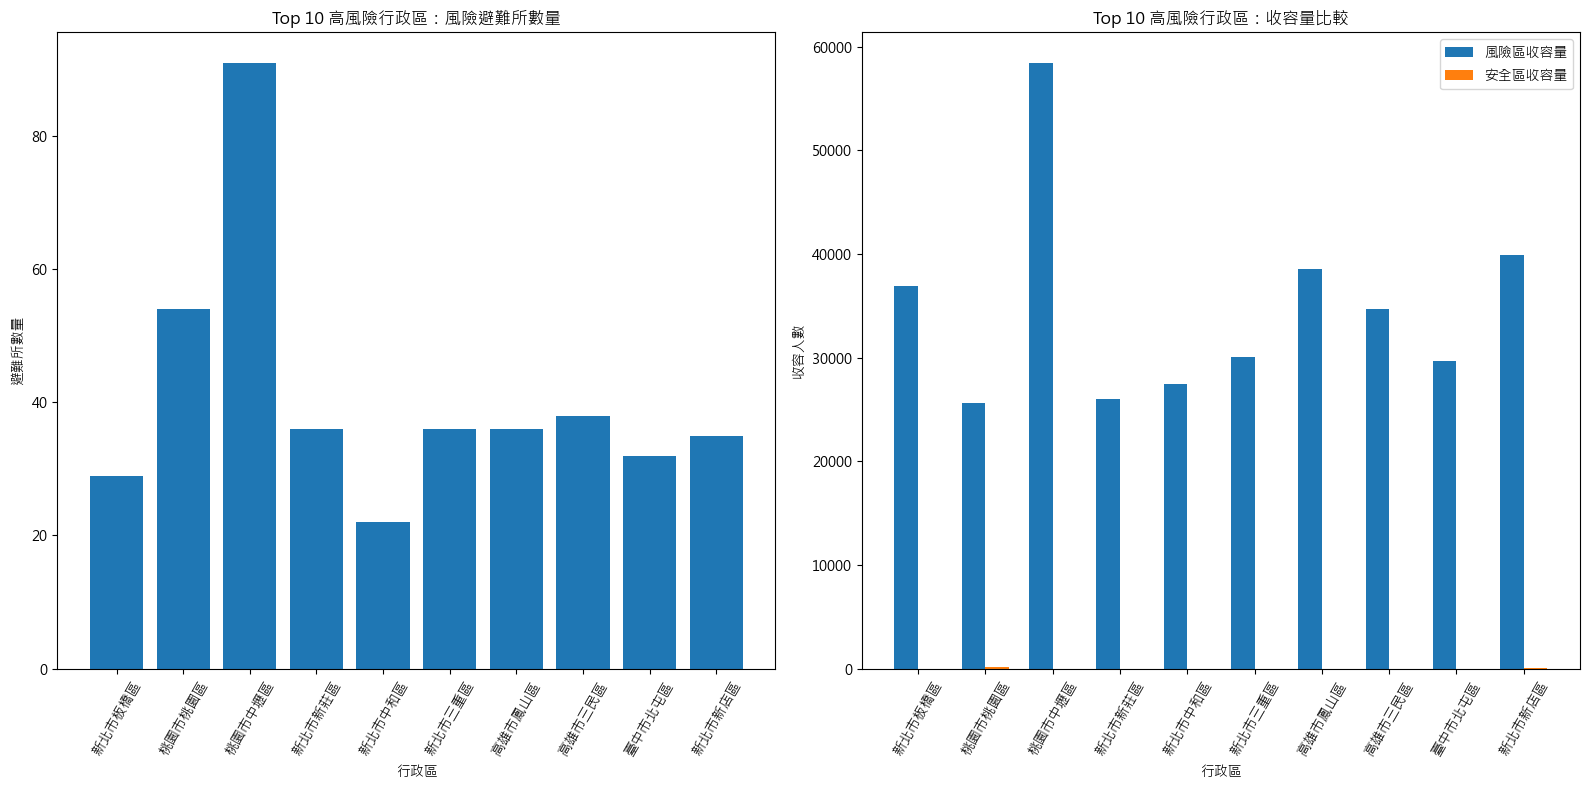

✅ 圖表已輸出：output\risk_map.png


In [7]:
print("📊 建立 Top10 高風險行政區長條圖...")

# =========================================================
# 1. 準備 Top 10 高風險行政區資料
# =========================================================

top10_risk_county = district_stats.sort_values(
    "收容量缺口",
    ascending=False
).head(10).copy()

# 計算風險避難所總數
risk_shelter_cols = [
    col for col in ["高風險_避難所", "中風險_避難所", "低風險_避難所"]
    if col in top10_risk_county.columns
]

top10_risk_county["風險避難所總數"] = top10_risk_county[risk_shelter_cols].sum(axis=1)

# 計算風險區收容量
risk_capacity_cols = [
    col for col in ["高風險_收容", "中風險_收容", "低風險_收容"]
    if col in top10_risk_county.columns
]

top10_risk_county["風險區收容量"] = top10_risk_county[risk_capacity_cols].sum(axis=1)

display(top10_risk_county[[
    "縣市及鄉鎮市區",
    "風險避難所總數",
    "風險區收容量",
    "安全_收容",
    "收容量缺口"
]])

# =========================================================
# 2. 長條圖：避難所數量 vs 收容量
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(CHART_WIDTH, CHART_HEIGHT/1.5))

# ---- 左圖：風險避難所數量 ----
axes[0].bar(
    top10_risk_county["縣市及鄉鎮市區"],
    top10_risk_county["風險避難所總數"]
)

axes[0].set_title("Top 10 高風險行政區：風險避難所數量")
axes[0].set_xlabel("行政區")
axes[0].set_ylabel("避難所數量")
axes[0].tick_params(axis='x', rotation=60)

# ---- 右圖：收容量比較 ----
x = np.arange(len(top10_risk_county))
width = 0.35

axes[1].bar(
    x - width/2,
    top10_risk_county["風險區收容量"],
    width=width,
    label="風險區收容量"
)

axes[1].bar(
    x + width/2,
    top10_risk_county["安全_收容"],
    width=width,
    label="安全區收容量"
)

axes[1].set_title("Top 10 高風險行政區：收容量比較")
axes[1].set_xlabel("行政區")
axes[1].set_ylabel("收容人數")

axes[1].set_xticks(x)
axes[1].set_xticklabels(top10_risk_county["縣市及鄉鎮市區"], rotation=60)

axes[1].legend()

plt.tight_layout()

# =========================================================
# 3. 儲存 PNG
# =========================================================

output_path = os.path.join(OUTPUT_DIR, "risk_map.png")

plt.savefig(output_path, dpi=MAP_DPI, bbox_inches="tight")

plt.show()

print(f"✅ 圖表已輸出：{output_path}")